# Laboratorio 5 - Naive Bayes


#### Importación de librerías

In [1]:
%pip install numpy pandas matplotlib seaborn scipy pyreadr scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pyreadr
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')
RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


### Carga y preprocesamiento del dataset

Se reproduce el mismo pipeline de preprocesamiento del Lab 4 para garantizar que los conjuntos de entrenamiento y prueba sean idénticos a los usados en los modelos anteriores.

In [3]:
# Cargar el archivo .Rdata
resultado = pyreadr.read_r('data/listings.Rdata')
df = resultado[list(resultado.keys())[0]]
print('Dimensiones del dataset:', df.shape)

Dimensiones del dataset: (171748, 80)


In [4]:
# Limpiar la columna price
df['price'] = (
    df['price']
    .astype(str)
    .str.replace(r'[$,]', '', regex=True)
)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df[df['price'].notna()]
df = df[df['price'] > 0]

# Eliminar outliers extremos (percentil 99)
limite_superior = df['price'].quantile(0.99)
df = df[df['price'] <= limite_superior]
print(f'Filas después de limpieza: {df.shape[0]}')
print(f'Rango de precio: {df["price"].min():.2f} – {df["price"].max():.2f}')

Filas después de limpieza: 75531
Rango de precio: 8.00 – 20000.00


In [5]:
# Seleccionar columnas del modelo
columnas_modelo = [
    'price', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'availability_365',
    'calculated_host_listings_count', 'host_is_superhost',
    'neighbourhood_cleansed', 'instant_bookable'
]
columnas_modelo = [c for c in columnas_modelo if c in df.columns]
df_modelo = df[columnas_modelo].copy()

# Imputar nulos numéricos con mediana
cols_num = df_modelo.select_dtypes(include=[np.number]).columns.tolist()
cols_num = [c for c in cols_num if c != 'price']
for col in cols_num:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

# Imputar nulos categóricos con la moda
cols_cat = df_modelo.select_dtypes(include='object').columns.tolist()
for col in cols_cat:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].mode()[0])

# Label Encoding
le = LabelEncoder()
df_procesado = df_modelo.copy()
cols_a_codificar = df_procesado.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cols_a_codificar:
    df_procesado[col] = le.fit_transform(df_procesado[col].astype(str))

print('Preprocesamiento completado.')
print('Nulos restantes:', df_procesado.isnull().sum().sum())
print('Dimensiones finales:', df_procesado.shape)

Preprocesamiento completado.
Nulos restantes: 0
Dimensiones finales: (75531, 21)


### División en conjuntos de entrenamiento y prueba

Se usa la misma semilla (`random_state=42`), la misma proporción (70/30) y la misma estratificación por `room_type` que en el Lab 4. Esto garantiza que los conjuntos sean comparables con los modelos anteriores.

In [6]:
y = df_procesado['price']
X = df_procesado.drop(columns=['price'])

estrato = X['room_type'] if 'room_type' in X.columns else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    train_size=0.70,
    stratify=estrato,
    random_state=42        
)

print('Conjunto de entrenamiento (X_train):', X_train.shape)
print('Conjunto de prueba     (X_test): ', X_test.shape)
print('Labels entrenamiento   (y_train):', y_train.shape)
print('Labels prueba          (y_test): ', y_test.shape)

Conjunto de entrenamiento (X_train): (52871, 20)
Conjunto de prueba     (X_test):  (22660, 20)
Labels entrenamiento   (y_train): (52871,)
Labels prueba          (y_test):  (22660,)


### Función auxiliar de métricas de regresión

Se reutiliza la misma función del Lab 4 para mantener consistencia en la comparación.

In [7]:
from sklearn.metrics import mean_squared_error

def evaluar_regresion(nombre, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f'── {nombre} ──')
    print(f'RMSE: {rmse:>10.2f}  (error en unidades de precio)')
    print(f'MAE: {mae:>10.2f}  (error absoluto promedio)')
    print(f'R²: {r2:>10.4f}  (varianza explicada)')
    print()
    return {'modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

resultados_regresion = []
print('Función auxiliar definida.')

Función auxiliar definida.


### Actividad 1 – Modelo de Regresión con Naive Bayes

Se entrena un modelo GaussianNB para predecir el precio numérico (`price`) de los alquileres.  
Se usa el mismo conjunto de entrenamiento del Lab 4 para que los resultados sean comparables.

**¿Por qué GaussianNB?**  
Todas las variables predictoras son numéricas (después del preprocesamiento con Label Encoding), por lo que se asume que cada una sigue una distribución normal condicionada a la clase. Esto corresponde al tipo Gaussiano del algoritmo.

In [14]:
# Modelo Naive Bayes Gaussiano base
nb_regresion = GaussianNB()
nb_regresion.fit(X_train, y_train)

y_pred_nb = nb_regresion.predict(X_test)

r_nb_base = evaluar_regresion('Naive Bayes – Regresión', y_test, y_pred_nb)
resultados_regresion.append(r_nb_base)

── Naive Bayes – Regresión ──
RMSE:    1282.78  (error en unidades de precio)
MAE:     687.75  (error absoluto promedio)
R²:    -0.9462  (varianza explicada)



El modelo Naive Bayes Gaussiano base obtuvo un RMSE de 1,282.78, lo que significa que en promedio el modelo se equivoca por aproximadamente $1,282 al predecir el precio por noche de una propiedad. El MAE de 687.75 indica que el error absoluto promedio es de $687, y el R² negativo de -0.9462 es una señal clara de que el modelo está prediciendo peor que simplemente usar la media del precio como predicción constante. Un R² negativo ocurre cuando el modelo introduce más error del que elimina, lo que sugiere que la suposición de independencia entre variables que hace Naive Bayes es demasiado fuerte para este dataset, donde variables como accommodates, bedrooms y bathrooms están altamente correlacionadas entre sí.

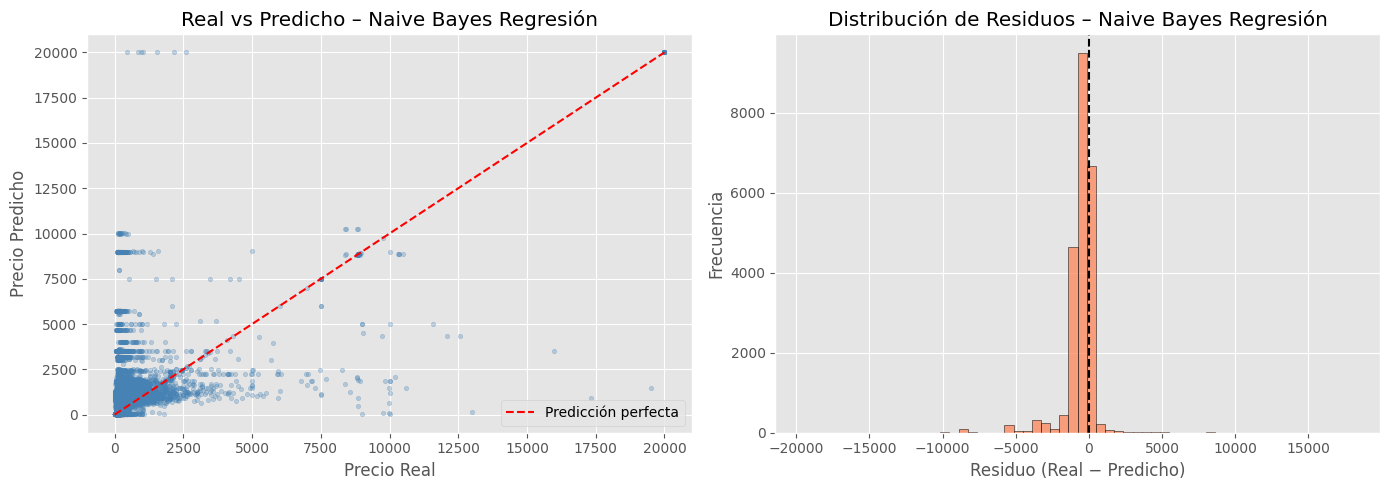

In [15]:
# Gráfica: Valores reales vs predichos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs predicho
axes[0].scatter(y_test, y_pred_nb, alpha=0.3, color='steelblue', s=10)
lim = float(max(y_test.max(), y_pred_nb.max()))
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real')
axes[0].set_ylabel('Precio Predicho')
axes[0].set_title('Real vs Predicho – Naive Bayes Regresión')
axes[0].legend()

# Distribución de residuos
residuos_nb = y_test.values - y_pred_nb
axes[1].hist(residuos_nb, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residuo (Real − Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos – Naive Bayes Regresión')

plt.tight_layout()
plt.show()

En la gráfica de Real vs Predicho se puede observar que la mayoría de las predicciones se concentran en valores muy bajos (cerca de 0), independientemente del precio real, lo que confirma que el modelo no está capturando la variabilidad del precio. Destaca una franja vertical de puntos predichos alrededor de 0–2,000 para precios reales de hasta 20,000, indicando que el modelo subestima sistemáticamente los precios altos. En la distribución de residuos se observa una fuerte asimetría hacia la izquierda (residuos negativos dominantes), lo que confirma esta subestimación sistemática: el modelo predice valores mucho más bajos que los reales en la mayoría de los casos, concentrando casi todos los residuos en un pico alrededor de 0 pero con una cola larga hacia -20,000.